<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# 🐼 Pandas Cheat Sheet – Demo Notebook
Dieses Notebook zeigt grundlegende Pandas-Workflows mit kleinen Beispieldatensätzen.

**Enthaltene Dateien:**
- `people.csv`
- `sales.csv`
- `timeseries.csv`
- `missing.csv`


## 1) Setup & Import

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Anzeigen von mehreren Spalten ohne Umbruch (optional)
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

%matplotlib inline


SyntaxError: invalid syntax (2070242633.py, line 6)

## 2) Daten erzeugen

### Series

In [3]:
series_0 = pd.Series([10, 20, 30], name="Werte")
series_1 = pd.Series(data = [10, 20, 30], index=['a', 'b', 'c'], name="Values")

print("#####")
print(series_0)
print("#####")
print(series_1, series_1['b'], sep='\n')
print("#####")

#####
0    10
1    20
2    30
Name: Werte, dtype: int64
#####
a    10
b    20
c    30
Name: Values, dtype: int64
20
#####


### DataFrame

In [6]:
data = {"Name": ["Franz", "Christoph", "Werner"],
        "Alter": [42, 41,44],
        "Kürzl": ["REFR", "SCRE", "GITS"]}
print(data)
dataframe = pd.DataFrame(data=data, index=['a', 'b', 'c'])
dataframe


{'Name': ['Franz', 'Christoph', 'Werner'], 'Alter': [42, 41, 44], 'Kürzl': ['REFR', 'SCRE', 'GITS']}


,Name,Alter,Kürzl
a,Franz,42,REFR
b,Christoph,41,SCRE
c,Werner,44,GITS


## 2) Daten laden

In [7]:
import os
base = "./../data"
people_path = os.path.join(base, "people.csv")
sales_path = os.path.join(base, "sales.csv")
ts_path = os.path.join(base, "timeseries.csv")
missing_path = os.path.join(base, "missing.csv")

people = pd.read_csv(people_path)
sales = pd.read_csv(sales_path, parse_dates=["date"])
timeseries = pd.read_csv(ts_path, parse_dates=["date"])
missing_df = pd.read_csv(missing_path)

people.head(), sales.head(), timeseries.head(), missing_df.head(3) , sales.sample(5)

(   id   name  age      city
 0   1   Anna   23      Wien
 1   2    Ben   31      Graz
 2   3  Carla   29      Linz
 3   4    Dio   41      Wien
 4   5    Eva   35  Salzburg,
    sale_id       date      city product  price  quantity   total
 0      101 2024-01-07      Linz       A  45.92         2   91.84
 1      102 2024-01-20      Linz       C  16.65         1   16.65
 2      103 2024-01-15      Linz       C  34.81         4  139.24
 3      104 2024-01-11      Graz       A  19.03         4   76.12
 4      105 2024-01-08  Salzburg       A  28.40         4  113.60,
         date  value
 0 2024-01-01  51.40
 1 2024-01-02  53.03
 2 2024-01-03  56.43
 3 2024-01-04  57.54
 4 2024-01-05  58.00,
    id   name   age  city
 0   1   Anna  23.0  Wien
 1   2    Ben  31.0  Graz
 2   3  Carla   NaN  Linz,
     sale_id       date      city product  price  quantity  total
 18      119 2024-01-12      Wien       C  17.21         3  51.63
 17      118 2024-01-12  Salzburg       A  22.49         3  67.4

## 3) Erste Blicke auf die Daten

In [9]:
people.info(verbose=True)
people.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5 non-null      int64 
 1   name    5 non-null      object
 2   age     5 non-null      int64 
 3   city    5 non-null      object
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes


,id,name,age,city
count,5.000000,5,5.000000,5
unique,NaN,5,NaN,4
top,NaN,Anna,NaN,Wien
freq,NaN,1,NaN,2
mean,3.000000,NaN,31.800000,NaN
std,1.581139,NaN,6.723095,NaN
min,1.000000,NaN,23.000000,NaN
25%,2.000000,NaN,29.000000,NaN
50%,3.000000,NaN,31.000000,NaN
75%,4.000000,NaN,35.000000,NaN


## 4) Auswahl & Filtern

In [16]:
# Eine Spalte
print(people['name'].head())
print("#" * 50)

# Mehrere Spalten
print(people[['name', 'age']].head())
print("#" * 50)

# Zeilen filtern
print(people[people['city'] == 'Wien'])
print("#" * 50)

# Komplexere Bedingung
print(people[(people['age'] >= 30) & (people['city'].isin(['Wien', 'Graz']))])

0     Anna
1      Ben
2    Carla
3      Dio
4      Eva
Name: name, dtype: object
##################################################
    name  age
0   Anna   23
1    Ben   31
2  Carla   29
3    Dio   41
4    Eva   35
##################################################
   id  name  age  city
0   1  Anna   23  Wien
3   4   Dio   41  Wien
##################################################
   id name  age  city
1   2  Ben   31  Graz
3   4  Dio   41  Wien


## 5) Bearbeiten & Erzeugen

In [10]:
# Neue Spalte aus Rechenoperation
people = people.copy()
print(people.head())
people['age_next_year'] = people['age'] + 1
print(people.head())
print("#" * 50)

# Spalten umbenennen
people_renamed = people.rename(columns={'name': 'Name', 'age': 'Age'})
print(people_renamed.head())
print("#" * 50)

# Zeilen/Spalten löschen
people_dropcol = people_renamed.drop(columns=['age_next_year'])
people_droprow = people_renamed.drop(index=[0])

people.head(), people_renamed.head(), people_dropcol.head(), people_droprow.head()

   id   name  age      city
0   1   Anna   23      Wien
1   2    Ben   31      Graz
2   3  Carla   29      Linz
3   4    Dio   41      Wien
4   5    Eva   35  Salzburg
   id   name  age      city  age_next_year
0   1   Anna   23      Wien             24
1   2    Ben   31      Graz             32
2   3  Carla   29      Linz             30
3   4    Dio   41      Wien             42
4   5    Eva   35  Salzburg             36
##################################################
   id   Name  Age      city  age_next_year
0   1   Anna   23      Wien             24
1   2    Ben   31      Graz             32
2   3  Carla   29      Linz             30
3   4    Dio   41      Wien             42
4   5    Eva   35  Salzburg             36
##################################################


(   id   name  age      city  age_next_year
 0   1   Anna   23      Wien             24
 1   2    Ben   31      Graz             32
 2   3  Carla   29      Linz             30
 3   4    Dio   41      Wien             42
 4   5    Eva   35  Salzburg             36,
    id   Name  Age      city  age_next_year
 0   1   Anna   23      Wien             24
 1   2    Ben   31      Graz             32
 2   3  Carla   29      Linz             30
 3   4    Dio   41      Wien             42
 4   5    Eva   35  Salzburg             36,
    id   Name  Age      city
 0   1   Anna   23      Wien
 1   2    Ben   31      Graz
 2   3  Carla   29      Linz
 3   4    Dio   41      Wien
 4   5    Eva   35  Salzburg,
    id   Name  Age      city  age_next_year
 1   2    Ben   31      Graz             32
 2   3  Carla   29      Linz             30
 3   4    Dio   41      Wien             42
 4   5    Eva   35  Salzburg             36)

## 6) Gruppieren & Aggregieren

In [14]:
# Durchschnittlicher Umsatz pro Stadt
sales_city = sales.groupby('city')['total'].mean().reset_index().sort_values('total', ascending=False)
print(sales_city)

# Mehrere Aggregationen auf einmal
sales_agg = sales.groupby(['city', 'product']).agg(
    total_sum=('total', 'sum'),
    qty_sum=('quantity', 'sum'),
    price_mean=('price', 'mean')
).reset_index()
sales_agg.head()

       city      total
2  Salzburg  92.377143
1      Linz  72.296250
0      Graz  53.787500
3      Wien  51.630000


,city,product,total_sum,qty_sum,price_mean
0,Graz,A,76.12,4,19.030000
1,Graz,B,139.03,3,46.343333
2,Linz,A,159.67,7,28.936667
3,Linz,B,199.40,5,39.880000
4,Linz,C,219.30,9,25.197500


## 7) Sortieren

In [15]:
sales.sort_values(['city', 'total'], ascending=[True, False]).sample(10)

,sale_id,date,city,product,price,quantity,total
3,104,2024-01-11,Graz,A,19.03,4,76.12
14,115,2024-01-06,Salzburg,B,13.82,3,41.46
9,110,2024-01-04,Graz,B,47.28,1,47.28
13,114,2024-01-12,Linz,A,8.98,4,35.92
15,116,2024-01-02,Linz,C,7.04,3,21.12
1,102,2024-01-20,Linz,C,16.65,1,16.65
4,105,2024-01-08,Salzburg,A,28.40,4,113.60
18,119,2024-01-12,Wien,C,17.21,3,51.63
16,117,2024-01-01,Salzburg,C,19.64,1,19.64
11,112,2024-01-03,Linz,A,31.91,1,31.91


## 8) Zusammenführen / Merge

In [16]:
# Beispiel: Nehmen wir an, people hat 'city' und wir möchten Durchschnittsumsatz je Stadt joinen
people_enriched = people.merge(sales_city, on='city', how='left')
people_enriched.head(10)

,id,name,age,city,age_next_year,total
0,1,Anna,23,Wien,24,51.630000
1,2,Ben,31,Graz,32,53.787500
2,3,Carla,29,Linz,30,72.296250
3,4,Dio,41,Wien,42,51.630000
4,5,Eva,35,Salzburg,36,92.377143


## 9) Fehlende Werte

In [21]:
missing_df.head(), missing_df.isna().sum()

(   id   name   age  city
 0   1   Anna  23.0  Wien
 1   2    Ben  31.0  Graz
 2   3  Carla   NaN  Linz
 3   4    Dio  41.0  Wien
 4   5    Eva  35.0   NaN,
 id      0
 name    0
 age     1
 city    1
 dtype: int64)

In [22]:
# Entfernen von Zeilen mit NaN
drop_na = missing_df.dropna()
drop_na

,id,name,age,city
0,1,Anna,23.0,Wien
1,2,Ben,31.0,Graz
3,4,Dio,41.0,Wien


In [23]:
# Imputation: NaN füllen
fill_na = missing_df.copy()
fill_na['age'] = fill_na['age'].fillna(fill_na['age'].median())
fill_na['city'] = fill_na['city'].fillna('Unbekannt')
fill_na, fill_na.isna().sum()

(   id   name   age       city
 0   1   Anna  23.0       Wien
 1   2    Ben  31.0       Graz
 2   3  Carla  33.0       Linz
 3   4    Dio  41.0       Wien
 4   5    Eva  35.0  Unbekannt,
 id      0
 name    0
 age     0
 city    0
 dtype: int64)

## 10) Zeitreihen & Plotten

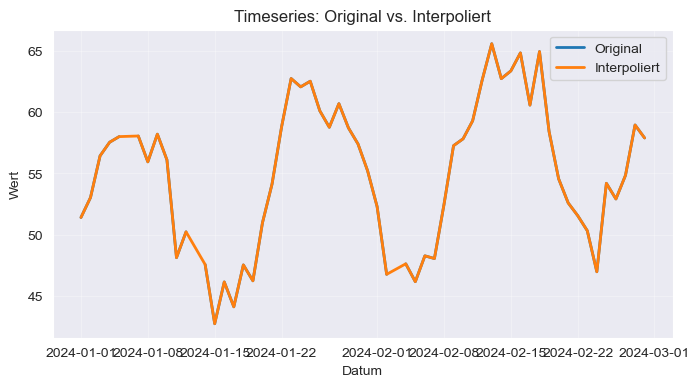

In [24]:
timeseries = timeseries.sort_values('date').set_index('date')

# Einfache Vorverarbeitung: fehlende Werte interpolieren
ts_interp = timeseries['value'].interpolate()

# Plot
plt.figure(figsize=(8,4))
plt.plot(timeseries.index, timeseries['value'], label='Original', linewidth=2)
plt.plot(ts_interp.index, ts_interp.values, label='Interpoliert', linewidth=2)
plt.title('Timeseries: Original vs. Interpoliert')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11) Exportieren

In [27]:
# DataFrame exportieren
people_enriched.to_csv(os.path.join(base, 'people_enriched.csv'), index=False)
os.path.join(base, 'people_enriched.csv')

'./../data\\people_enriched.csv'